In [ ]:
# Harold Downs III
# MET290 Research Collab
# Dr. Barber
# This is code that processes one variable of interest to our group project
# I have neither given or received, nor have I tolerated others' use of unauthorized aid X. Harold Downs III

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from IPython.display import display # Explicitly import display

# Load the CSV file
tornado_df = pd.read_csv('/content/ed876720075e3037c17b58e8762da952.csv')

# Display the first few rows and columns to understand the data
print("First 5 rows of the DataFrame:")
display(tornado_df.head())
print("\nDataFrame columns:")
print(tornado_df.columns)

First 5 rows of the DataFrame:


,ID,Countries,States,Start Time,Start Latitude,Start Longitude,End Latitude,End Longitude,Rating,Path Length (mi),Path Width (yds),Injuries,Fatalities,Comments,Sources
0,SPC55504_NCEI294080-294083-294084-294085,US,MN,2011-05-22T19:13:00Z,44.960,-93.347,45.132,-93.214,EF1,13.6,880.0,48,1,[object Object],SPC (https://www.spc.noaa.gov/wcm/#data); NCEI...
1,SPC55505_NCEI300438-301132,US,MN;IA,2011-05-22T19:33:00Z,43.409,-92.493,43.579,-91.972,EF2,28.7,250.0,3,0,[object Object],SPC (https://www.spc.noaa.gov/wcm/#data); NCEI...
2,SPC55506_NCEI319067,US,WI,2011-05-22T19:33:00Z,45.777,-90.645,45.821,-90.619,EF1,3.3,600.0,0,0,[object Object],SPC (https://www.spc.noaa.gov/wcm/#data); NCEI...
3,SPC55507_NCEI309324,US,MO,2011-05-22T19:38:00Z,39.180,-93.860,39.180,-93.855,EF0,0.2,40.0,0,0,[object Object],SPC (https://www.spc.noaa.gov/wcm/#data); NCEI...
4,SPC55508_NCEI307316,US,IA,2011-05-22T19:40:00Z,41.792,-92.206,41.822,-92.142,EF2,3.9,75.0,0,0,[object Object],SPC (https://www.spc.noaa.gov/wcm/#data); NCEI...



DataFrame columns:
Index(['ID', 'Countries', 'States', 'Start Time', 'Start Latitude',
       'Start Longitude', 'End Latitude', 'End Longitude', 'Rating',
       'Path Length (mi)', 'Path Width (yds)', 'Injuries', 'Fatalities',
       'Comments', 'Sources'],
      dtype='object')


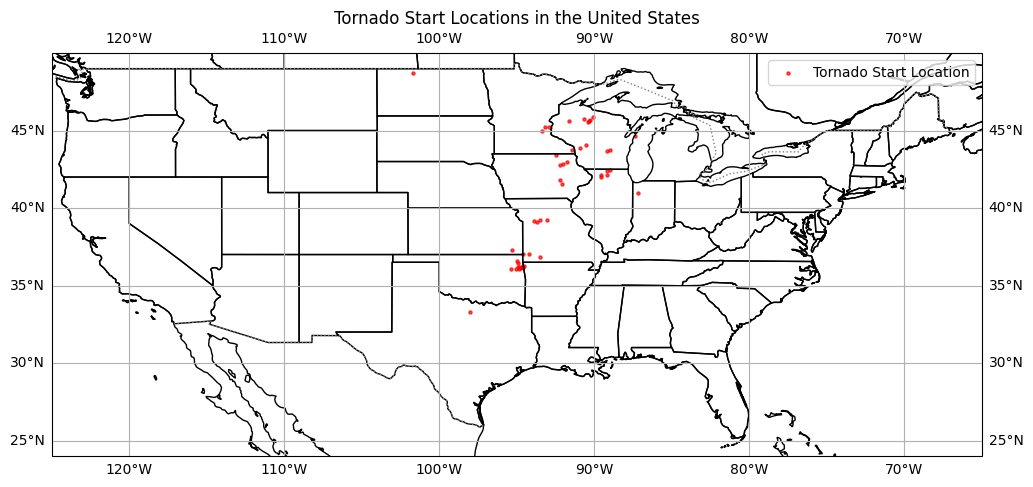

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf

# Assuming 'Start Latitude' and 'Start Longitude' represent the starting latitude and longitude of the tornadoes
# Filter out any rows with NaN values in these columns to avoid plotting errors
tornado_df_clean = tornado_df.dropna(subset=['Start Latitude', 'Start Longitude'])

# Making Plot
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geopolitical features
ax.coastlines(resolution='50m')
ax.add_feature(cf.STATES, edgecolor='black') # Use cf.STATES
ax.add_feature(cf.BORDERS, linestyle=':', edgecolor='gray') # Use cf.BORDERS

# Plot the tornado starting points
ax.scatter(tornado_df_clean['Start Longitude'], tornado_df_clean['Start Latitude'],
           color='red', marker='o', s=5, alpha=0.7,
           transform=ccrs.PlateCarree(), label='Tornado Start Location')

# Set the extent for the contiguous United States for a better view
ax.set_extent([-125, -65, 24, 50], crs=ccrs.PlateCarree())

# Add gridlines and labels
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

plt.title('Tornado Start Locations in the United States')
plt.legend()
plt.show()